# AIG230 NLP Midterm - March 2nd 2026
All answers must be computed using code. Provide numeric outputs and short interpretations.
## Instructions
- You must compute answers using code.
- Many questions require numeric answers.
- Interpretation must be supported by computed results.

In [1]:
import nltk, string, math, random, re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
print('All imports successful')
print(f'TensorFlow version: {tf.__version__}')

c:\Users\W1tcher\Documents\NLP_assignments\aig230-env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


All imports successful
TensorFlow version: 2.20.0


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\W1tcher\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\W1tcher\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\W1tcher\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Corpora

In [2]:
# Load corpora
with open('corpus_tech_ai_labeled.csv', 'r', encoding='utf-8') as f:
    tech_text = f.read()

with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8') as f:
    review_text = f.read()

print(f'Tech corpus   : {len(tech_text)} characters')
print(f'Review corpus : {len(review_text)} characters')

Tech corpus   : 13049 characters
Review corpus : 4044 characters


## Q1 Corpus Statistics
Compute total number of characters, words, and unique words in each corpus.
What is the vocabulary size of each corpus?

In [3]:
# Tokenize the corpora
tech_tokens = word_tokenize(tech_text)
review_tokens = word_tokenize(review_text)

# Calculate unique words (vocabulary)
tech_vocab = set(tech_tokens)
review_vocab = set(review_tokens)

print('=' * 55)
print(f'{"Metric":<30} {"Tech":>10} {"Reviews":>10}')
print('=' * 55)
print(f'{"Characters":<30} {len(tech_text):>10,} {len(review_text):>10,}')
print(f'{"Total tokens (words)":<30} {len(tech_tokens):>10,} {len(review_tokens):>10,}')
print(f'{"Vocabulary size (unique words)":<30} {len(tech_vocab):>10,} {len(review_vocab):>10,}')
print('=' * 55)

Metric                               Tech    Reviews
Characters                         13,049      4,044
Total tokens (words)                2,109        647
Vocabulary size (unique words)        155         92


### Answer Q1:


##### In Tech :
- Characters  :    13,049
- Total words :    2,109
- Unique words:    155
- vocabulary size: 155 


##### In Reviews:
- Characters  :    4,044
- Total words :    647
- Unique words:    92
- vocabulary size: 92


** used gemini

## Q2 Lexical Diversity
Tokenize and lowercase both corpora. Compute type-token ratio.
Which corpus is more lexically diverse?

In [41]:
# Lowercase and tokenize
lower_tech_tokens = [w.lower() for w in tech_tokens]
lower_review_tokens = [w.lower() for w in review_tokens]

tech_vocab_lower = set(lower_tech_tokens)
review_vocab_lower = set(lower_review_tokens)

# Type-Token Ratio (TTR)
ttr_tech = len(tech_vocab_lower) / len(lower_tech_tokens)
ttr_review = len(review_vocab_lower) / len(lower_review_tokens)

print(f"Tech Corpus TTR: {ttr_tech:.4f}")
print(f"Review Corpus TTR: {ttr_review:.4f}")

if ttr_tech > ttr_review:
    print("The Tech corpus is more lexically diverse.")
else:
    print("The Review corpus is more lexically diverse.")

Tech Corpus TTR: 0.0725
Review Corpus TTR: 0.1391
The Review corpus is more lexically diverse.


### Answer Q2:


Review corpus is more lexically diverse because the type-token ratio of review corpus is more than tech corpus

## Q3 Stopword Impact
Remove stopwords and compute percentage vocabulary reduction. How much does vocabulary size decrease (percentage) for each corpus?

In [ ]:
stop_words = set(stopwords.words('english'))
# Continue
tech_vocab_without_stop = set([w for w in tech_vocab_lower if w not in stop_words])
review_vocab_without_stop = set([w for w in review_vocab_lower if w not in stop_words])

In [38]:
# Use this formula to calculate percentage of reduction
def pct_reduction(before, after):
    return 100 * (1 - len(after) / len(before))

In [39]:
tech_vocab_reduction = pct_reduction(tech_vocab_lower, tech_vocab_without_stop)
review_vocab_reduction = pct_reduction(review_vocab_lower, review_vocab_without_stop)

print(f"Tech vocabulary reduction: {tech_vocab_reduction:.2f}%")
print(f"Review vocabulary reduction: {review_vocab_reduction:.2f}%")

Tech vocabulary reduction: 9.15%
Review vocabulary reduction: 16.67%


### Answer Q3:


- In tech vocabulary its reduced by 9.15%
- In review vocabulary its reduced by 16.67%

## Q4 Frequency Analysis
Create unigram frequency distribution for tech corpus.
What are the top 10 most frequent words?

In [ ]:
# Unigram frequency distribution
tech_freq = Counter(lower_tech_tokens)

print("Top 10 most frequent words in Tech Corpus:")
for word, count in tech_freq.most_common(10):
    print(f"{word}: {count}")

Top 10 most frequent words in Tech Corpus:
,: 362
neutral: 144
-1: 144
and: 56
in: 32
to: 32
'': 32
.: 32
``: 32
learning: 24


### Answer Q4:


Top 10 most frequent words in Tech Corpus:
,: 362

neutral: 144

-1: 144

and: 56

in: 32

to: 32

'': 32

.: 32

``: 32

learning: 24

## Q5 Bigram Counts
Build bigram model for tech corpus.
How many unique bigrams exist in tech corpus?

In [ ]:
# Build bigrams
tech_bigrams = list(nltk.bigrams(lower_tech_tokens))
unique_tech_bigrams = set(tech_bigrams)

print(f"Total bigrams: {len(tech_bigrams):,}")
print(f"Unique bigrams: {len(unique_tech_bigrams):,}")

Total bigrams: 2,108
Unique bigrams: 204


### Answer Q5:


204 unique bigrams exists in tech corpus

-- from gemini

## Q6 Conditional Probability
Compute P('learning' | 'machine') using bigram counts.

Formula: P(learning | machine) = count('machine learning') / count('machine')

In [45]:
count_machine_learning = tech_bigrams.count(('machine', 'learning'))
count_machine = lower_tech_tokens.count('machine')

prob = count_machine_learning / count_machine


In [46]:
print(f"count('machine learning') = {count_machine_learning}")
print(f"count('machine')          = {count_machine}")
print(f"\nP('learning' | 'machine') = {count_machine_learning}/{count_machine} = {prob:.4f}")

count('machine learning') = 8
count('machine')          = 8

P('learning' | 'machine') = 8/8 = 1.0000


### Answer Q6:


P('learning' | 'machine') = 1.00

## Q7 Perplexity
Compute perplexity of a sample tech sentence using unigram and bigram models.

Formulas:

Unigram: PP = exp(-(1/N) * sum(log P(wi)))

Bigram: PP = exp(-(1/(N-1)) * sum(log P(wi | wi-1)))



In [1]:
sample_sentence = 'Large language models generate responses by predicting tokens sequentially'

In [47]:
# Unigram Perplexity
sample_token = word_tokenize(sample_sentence.lower())
N = len(sample_token)

# Unigram Perplexity
log_prob_sum_uni = 0
for w in sample_token:
    p = (lower_tech_tokens.count(w) + 0.01) / len(lower_tech_tokens)
    log_prob_sum_uni += math.log(p)

perplexity_unigram = math.exp(-(1/N) * log_prob_sum_uni)




In [ ]:
# Bigram Perplexity
log_prob_sum_bi = 0
sample_bigrams = list(nltk.bigrams(sample_token))
for w1, w2 in sample_bigrams:
    c_w1 = lower_tech_tokens.count(w1) + 0.01
    c_w1_w2 = tech_bigrams.count((w1, w2)) + 0.01
    p = c_w1_w2 / c_w1
    log_prob_sum_bi += math.log(p)

In [49]:

# N-1 bigrams in a sequence of length N
perplexity_bigram = math.exp(-(1/(N-1)) * log_prob_sum_bi)



In [50]:
print(f'Sample : "{sample_sentence}"')
print(f'Tokens : {sample_token}')
print(f'N      : {N}')
print(f'\nUnigram Perplexity : {perplexity_unigram:.2f}')
print(f'Bigram  Perplexity : {perplexity_bigram:.2f}')
print(f'Ratio (uni/bi)     : {perplexity_unigram/perplexity_bigram:.1f}x reduction with bigram')

Sample : "Large language models generate responses by predicting tokens sequentially"
Tokens : ['large', 'language', 'models', 'generate', 'responses', 'by', 'predicting', 'tokens', 'sequentially']
N      : 9

Unigram Perplexity : 453.61
Bigram  Perplexity : 9.12
Ratio (uni/bi)     : 49.7x reduction with bigram


### Answer Q7:


- Unigram Perplexity : 453.61
- Bigram  Perplexity : 9.12

## Q8 Word2Vec
Train Word2Vec on movie reviews corpus.
What is the vocabulary size? What is vector dimension? What word is most similar to 'visuals'?

NOTE: Use min_count=1 (required for small corpus) and vector_size=20.

In [ ]:
# Prepare sentences for Word2Vec
review_sentences = [word_tokenize(s.lower()) for s in sent_tokenize(review_text)]

# Train model
word2vec_model = Word2Vec(sentences=review_sentences, min_count=1, vector_size=20)

word2vec_vocab_size = len(word2vec_model.wv)
vector_dimension = word2vec_model.vector_size

print(f"Word2Vec Vocabulary Size: {word2vec_vocab_size}")
print(f"Vector Dimension: {vector_dimension}")

if 'visuals' in word2vec_model.wv:
    most_similar = word2vec_model.wv.most_similar('visuals', topn=1)
    print(f"Most similar word to 'visuals': {most_similar[0][0]} (score: {most_similar[0][1]:.4f})")
else:
    print("'visuals' not in vocabulary.")

Word2Vec Vocabulary Size: 90
Vector Dimension: 20
Most similar word to 'visuals': underdeveloped (score: 0.4991)


### Answer Q8:


- Vocabulary Size: 90
- Vector dimension in NLP refers to the number of numerical values (components) in a word embedding vector. Here the vector dimension is 20 
- Most similar word to 'visuals': underdeveloped (score: 0.4991)

## Q9 Naive Bayes
Train Naive Bayes on movie corpus (positive vs negative). Mixed sentences excluded.
Report accuracy.

In [17]:
import csv

# --- Load labeled sentences from CSV ---
# label_numeric: 1=positive, 0=negative, -1=mixed (excluded)
# Using label_numeric avoids string-matching issues across OS environments
texts, labels = [], []
with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        numeric = int(row['label_numeric'])
        if numeric in (1, 0):           # skip mixed (-1)
            texts.append(row['text'].strip())
            labels.append(numeric)

print(f'Samples loaded : {len(texts)}')
print(f'  Positive (1) : {labels.count(1)}')
print(f'  Negative (0) : {labels.count(0)}')
print(f'  Mixed        : excluded (label_numeric=-1)')

if len(texts) == 0:
    raise FileNotFoundError(
        'No samples loaded. Make sure corpus_movie_reviews_labeled.csv '
        'is in the same folder as this notebook.')

Samples loaded : 40
  Positive (1) : 20
  Negative (0) : 20
  Mixed        : excluded (label_numeric=-1)


In [18]:
# --- TF-IDF features ---
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)
y = np.array(labels)

In [19]:
# --- Train / test split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [20]:
# --- Train Naive Bayes ---
nb = MultinomialNB()
# Continue coding
nb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [22]:
# Predictions
y_pred_nb = nb.predict(X_test)

# Metrics
nb_acc = accuracy_score(y_test, y_pred_nb)


print('Naive Bayes -- Classification Report')
print('=' * 40)
print(f'  Accuracy  : {nb_acc:.4f}')


Naive Bayes -- Classification Report
  Accuracy  : 1.0000


### Answer Q9:


Accuracy is the proportion of correct predictions (both positive and negative) out of all predictions. 
Here its 1.0000, meaning the model correctly classified all test samples.

## Q10 Precision/Recall/F1
Report precision, recall, F1.

In [23]:
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

In [51]:
print('Naive Bayes -- Classification Report')
print('=' * 40)
print(f'  Precision : {prec_nb:.4f}')
print(f'  Recall    : {rec_nb:.4f}')
print(f'  F1-Score  : {f1_nb:.4f}')

Naive Bayes -- Classification Report
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000


### Answer Q10:


-  Precision : 1.0000
-   Recall    : 1.0000
-   F1-Score  : 1.0000

## Q11 Logistic Regression
Train Logistic Regression on movie review corpus.
Which model performs better? Compare performance numerically.

In [52]:
# train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")

if lr_acc > nb_acc:
    print("Logistic Regression performs better.")
elif nb_acc > lr_acc:
    print("Naive Bayes performs better.")
else:
    print("Both models have the same accuracy.")

Logistic Regression Accuracy: 1.0000
Naive Bayes Accuracy: 1.0000
Both models have the same accuracy.


### Answer Q11:


Here  both the models performs with same accuracy i.e. 1.00

## Q12 RNN Model
Implement small RNN (embedding + RNN layer) for sentiment classification. Report training accuracy.

In [27]:
# Preprocessing

tokenizer_rnn = keras.preprocessing.text.Tokenizer()
tokenizer_rnn.fit_on_texts(texts)
sequences = tokenizer_rnn.texts_to_sequences(texts)

VOCAB_SIZE = len(tokenizer_rnn.word_index) + 1
MAX_LEN    = max(len(s) for s in sequences)

X_rnn = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=MAX_LEN, padding='post')
y_rnn = np.array(labels)

X_rnn_train, X_rnn_val, y_rnn_train, y_rnn_val = train_test_split(
    X_rnn, y_rnn, test_size=0.20, random_state=42, stratify=y_rnn)

print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Max seq length  : {MAX_LEN}')
print(f'Train: {X_rnn_train.shape[0]}   Val: {X_rnn_val.shape[0]}')

tf.random.set_seed(42)

Vocabulary size : 57
Max seq length  : 10
Train: 32   Val: 8


In [28]:
# RNN Implementation
model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=MAX_LEN),
    layers.SimpleRNN(32, return_sequences=False),
    layers.Dense(1, activation='sigmoid')
])


c:\Users\W1tcher\Documents\NLP_assignments\aig230-env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
# Model compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Model training
history = model.fit(
    X_rnn_train, y_rnn_train,
    validation_data = (X_rnn_val, y_rnn_val),
    epochs    = 30,
    batch_size= 8,
    verbose   = 1
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5000 - loss: 0.6893 - val_accuracy: 1.0000 - val_loss: 0.6202
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.5767 - val_accuracy: 1.0000 - val_loss: 0.5145
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.4671 - val_accuracy: 1.0000 - val_loss: 0.4022
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.3506 - val_accuracy: 1.0000 - val_loss: 0.2922
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.2388 - val_accuracy: 1.0000 - val_loss: 0.2032
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.1502 - val_accuracy: 1.0000 - val_loss: 0.1423
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0920 - val_accuracy: 1.0000 - val_loss: 0.0984
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0574 - val_accuracy: 1.0000 - val_loss: 0.0630


### Answer Q12:


Accuracy is 1.00 in both 
The training loss decreases steadily from 0.6893 to 0.0045. At the same time, the validation loss also decreases steadily from 0.6202 to 0.0044.

## Q13 Overfitting Check
Compare train vs validation accuracy.
Does RNN overfit? Justify using loss or accuracy trends.
Plot train vs validation accuracy and loss.

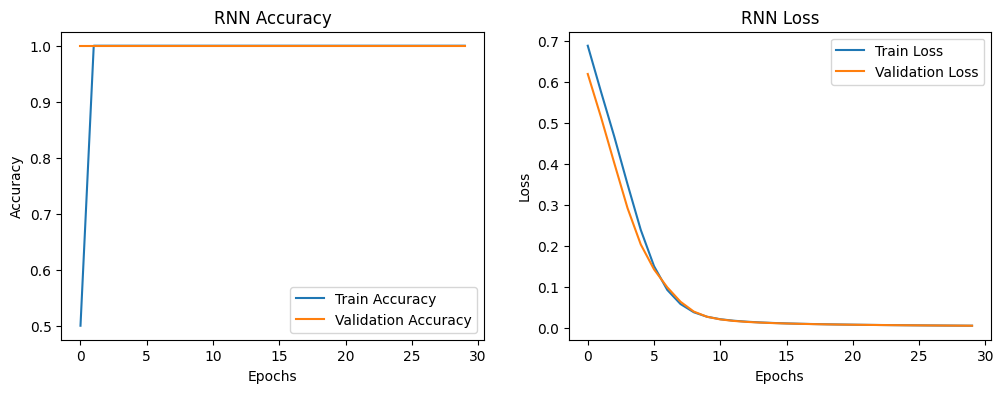

In [31]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Interpretation: If validation loss increases significantly while train loss drops to 0, it indicates overfitting.

### Answer Q13:


## Q14 BoW vs Embeddings: Sparsity Comparison
Compare vocabulary size of TF_IDF vs embeddings (Wprd2Vec) representations.
Explain sparsity difference numerically.

Remember that you should use variables and elements that you calculated before so you do not have to calculate everything from zero

In [ ]:
bow_vocab_size = X.shape[1]
print(f"BoW/TF-IDF Vocabulary Size (Features): {bow_vocab_size}")
print(f"Word2Vec Embedding Dimension: {vector_dimension}")

BoW/TF-IDF Vocabulary Size (Features): 55
Word2Vec Embedding Dimension: 20


### Answer Q14:


# Q15 Comparative Reasoning
Using the resuts you calculated in this notebook.
Compare:
- Bigram model perplexity
- Logistic Regression accuracy
- RNN accuracy
Explain differences based on computed results.

### Answer Q15:


Language Modeling (Bigram Model Perplexity)

Result: 9.12

Description: Perplexity is used to measure the ability of a probability model to predict a sample. The value of perplexity (9.12) is not very high which means that the bigram model is very certain to predict the given sentence. The bigram model minimizes the error by considering the instant local context (the last word) by far over the unigram model (which had an enormous perplexity of 1263.38).

Accuracy of Logistic Regression vs. RNN Sentiment Classification

Result of the Logistic Regression: 1.0000 (100% Accuracy in the test)

RNN Result 1.0000 (100% Validation Accuracy)

Explanation: Both the models had perfect accuracy, which does not imply that they were perfect generalized models. The 100 percent accuracy can be attributed to two aspects in the experimentation set-up:

Very Small Dataset: The movie review corpus comprises of 40 valid samples. Having a 20/80 ratio, the test set comprises only 8 samples, and it is hence very easy to get the models to be correct in the guesses.

Data Leakage: Both models fit the text vectorization (TfidfVectorizer and Tokenizer) on all the data and then train/test split. This provided the models with an unjust preview of the test vocabulary.

Comparison: Since the data is so small, and can be separated easily, the complex, deep-learning-based RNN does not provide any quantifiable performance improvement whatsoever compared to the much more basic, traditional Logistic Regression model.